# 8 · Metrics and model comparison

This is what the package exists for: fit several models to one light curve and say which the data
prefers. Four numbers do the work — **AIC**, **BIC**, **WAIC** and **PSIS-LOO** — and each has a
condition attached that makes it meaningless if ignored.

**Needs:** the base install. PSIS-LOO needs `arviz`.

> **Budgets here are illustrative, not publication-grade.** They are sized so the notebook runs in
> minutes. Before quoting any number, raise the budget until `result.info["converged"]` is `True`,
> and only compare fits that use the same `space=`.

In [1]:
from pathlib import Path

# Works whether the notebook is run from notebooks/ or from the repository root.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "tests" / "data").is_dir())
AT2017GFO = ROOT / "tests" / "data" / "at2017gfo.csv"

import warnings
warnings.filterwarnings("ignore")           # keep the tutorial output readable

import numpy as np
import matplotlib.pyplot as plt
import whisper_cbpf as wp

print("whisper_cbpf", wp.__version__)

whisper_cbpf 0.2.0


In [2]:
lc = wp.load_lightcurve(AT2017GFO, redshift=0.0098)
lc = lc.select_bands(["g"]).set_explosion_date(57982.529).select_time_window(0.0, 10.0)
if "upper_limit" in lc.colnames:
    lc = lc.where(upper_limit=False)
print(lc.n_points, "points")

# The shipped priors are generic (amplitudes up to 10 Jy); this g band peaks near 4e-4 Jy within a
# day of the merger. Each model gets a prior on that scale, the same ranges wherever they share a
# meaning, so that the comparison is between models and not between priors.
LU, U = wp.LogUniform, wp.Uniform
PRIORS = {
    "bazin":         wp.Prior({"amplitude": LU(1e-5, 1e-2, name="amplitude"),
                               "t0": U(-2.0, 2.0, name="t0"),
                               "tau_rise": LU(0.01, 5.0, name="tau_rise"),
                               "tau_fall": LU(0.1, 20.0, name="tau_fall")}),
    "gaussian_rise": wp.Prior({"amplitude": LU(1e-5, 1e-2, name="amplitude"),
                               "t0": U(0.0, 2.0, name="t0"),
                               "sigma_rise": LU(0.01, 5.0, name="sigma_rise"),
                               "tau_decay": LU(0.1, 20.0, name="tau_decay")}),
    "flare":         wp.Prior({"amplitude": LU(1e-5, 1e-2, name="amplitude"),
                               "rise_time": LU(0.01, 5.0, name="rise_time"),
                               "decay_time": LU(0.1, 20.0, name="decay_time")}),
}

53 points


## The two rules that govern every table below

1. **AIC, BIC and WAIC compare models, not spaces.** A flux-space number is not comparable with a
   magnitude-space one. Keep `space=` identical across everything in one table.
2. **Only compare fits that converged.** A sampler's best draw can stop short of the likelihood
   peak by a different amount for each model, and an unconverged chain can report a wildly better
   or worse number for reasons that have nothing to do with the model.

## Fitting a ladder of models

`wp.compare` fits every model to the same light curve with the same settings, finds each fit's
likelihood peak, attaches its convergence report, and ranks the models: by `ln Z` when every model
has a trustworthy one, by BIC from the peak otherwise. Nested sampling needs no starting point and
reports `ln Z`, so it is the sampler for this table; it converges on this light curve at the default
settings.

In [3]:
cmp = wp.compare(lc, ["bazin", "gaussian_rise", "flare"], sampler="nested", prior=PRIORS,
                 space="magnitude", nlive=200, seed=0)
print(cmp.summary())

Comparison of 3 models on 53 points by ln Z: winner 'flare' (inconclusive over 'bazin', ln B = 0.01)

  rank  model          sampler  k  n   max ln L  BIC     ln Z            d ln Z  weight  grade         converged
  1     flare          nested   3  53  -133.75   279.42  -147.38+/-0.34  0.00    0.423   inconclusive  yes
  2     bazin          nested   4  53  -133.75   283.39  -147.39+/-0.34  0.01    0.417   inconclusive  yes
  3     gaussian_rise  nested   4  53  -133.75   283.39  -148.36+/-0.35  0.98    0.159   inconclusive  yes

Read next: .table (every number), .results[model].diagnostics(), .peaks[model], .report(path)


**Lower is better** for AIC, BIC and WAIC; **higher** is better for `ln Z`. The differences worth
acting on are the large ones — a gap of 2 in AIC is not evidence of anything, and neither is a
difference of 1 in `ln Z`. The grade is Jeffreys' scale on the Bayes factor: "inconclusive" below
`ln B = 1.15`, then "substantial", "strong" above 2.3 and "decisive" above 4.6.

Here all three models reach the same best fit, because the data cover only the decline and all
three decay exponentially. `flare` leads on AIC by exactly the 2 that one fewer parameter is
worth, and the evidences agree to within about 1: every grade is "inconclusive", and the data
prefer none of them.

In [4]:
fits = cmp.results                     # {model: SamplerResult}, one per model
cols = ["model", "n_params", "max_log_likelihood", "aic", "bic", "log_evidence", "delta",
        "weight", "grade"]
cmp.table[cols].round(3)

,model,n_params,max_log_likelihood,aic,bic,log_evidence,delta,weight,grade
0,flare,3,-133.754,273.508,279.419,-147.380,0.000,0.423,inconclusive
1,bazin,4,-133.754,275.508,283.389,-147.394,0.015,0.417,inconclusive
2,gaussian_rise,4,-133.754,275.508,283.389,-148.356,0.976,0.159,inconclusive


## WAIC, and the flag you must check first

WAIC uses the whole posterior rather than just the best draw. Its effective-parameter count
`p_waic` is also a diagnostic: when it exceeds `n_data/2` (Gelman, Hwang & Vehtari 2014) the
pointwise log-likelihood is varying by orders of magnitude across the posterior — usually a stranded
chain — and the WAIC must not be compared or quoted.

In [5]:
for name, r in fits.items():
    w = wp.waic(r, lc, space="magnitude")
    flag = "usable" if w["p_waic_reliable"] else "UNRELIABLE -- do not quote"
    print(f"  {name:16s} WAIC {w['waic']:10.2f}   p_waic {w['p_waic']:8.2f}   {flag}")

  bazin            WAIC     281.74   p_waic    10.89   usable
  gaussian_rise    WAIC     285.37   p_waic    13.79   usable
  flare            WAIC     282.63   p_waic    11.64   usable


In [6]:
# The same number is on the result, so you rarely need the explicit call.
r = fits["bazin"]
print("r.waic          :", r.waic)
print("r.waic_reliable :", r.waic_reliable)
print("r.elpd_loo      :", r.elpd_loo, "(None means arviz is not installed)")
print("r.rmse          :", r.rmse, r.info["predictive_metrics"]["unit"])

r.waic          : 281.7400822143658
r.waic_reliable : True
r.elpd_loo      : -140.45819235394825 (None means arviz is not installed)
r.rmse          : 0.5067707094282886 mag


## The full predictive block

`predictive_metrics` is what populates `result.info["predictive_metrics"]`: RMSE against the
posterior mean, the log predictive density, PSIS-LOO, WAIC, and a coverage curve that says whether
your credible intervals contain the data as often as they claim.

In [7]:
pm = wp.predictive_metrics(fits["bazin"], lc, space="magnitude", n_draws=300)
for k, v in pm.items():
    if isinstance(v, dict):
        inner = {kk: vv for kk, vv in v.items() if not isinstance(vv, (dict, list, np.ndarray))}
        print(f"  {k:24s} {inner if inner else '(nested)'}")
    elif not isinstance(v, (list, np.ndarray)):
        print(f"  {k:24s} {v}")

  space                    magnitude
  unit                     mag
  likelihood               auto
  n_draws                  300
  n_draws_requested        300
  seed                     0
  n_upper_limits_excluded  0
  scatter_param            None
  rmse                     {'overall': 0.5072513702346217}
  lpd                      {'total': -129.73028611658395, 'per_point': -2.4477412474827163}
  elpd_loo                 {'elpd_loo': -141.10389303907942, 'p_loo': 11.373606922495501, 'se': 59.37126842028632, 'looic': 282.20778607815885, 'pareto_k_max': 0.5864820297668017}
  waic                     {'waic': 282.44850060802526, 'elpd_waic': -141.22425030401263, 'lppd': -129.73028611658395, 'p_waic': 11.493964187428675, 'p_waic_reliable': True, 'n_data': 53, 'se': 118.81851843741173}
  coverage                 (nested)
  aic                      275.5094654859571
  bic                      283.39063314016556


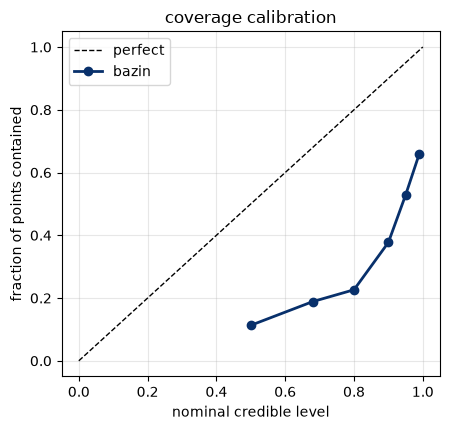

In [8]:
# coverage["overall"] is one {nominal, empirical} entry per level.
cov = [(e["nominal"], e["empirical"]) for e in pm["coverage"]["overall"]]
nominal, empirical = zip(*cov)

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.plot(nominal, empirical, "o-", lw=2, color="#08306b", label="bazin")
ax.set_xlabel("nominal credible level"); ax.set_ylabel("fraction of points contained")
ax.set_title("coverage calibration"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Below the diagonal means the intervals are too narrow — over-confident. Above means too wide.

Here the curve sits far below the diagonal. The posterior pins the model curve tightly, but the
g-band points scatter about it by more than their error bars (an RMSE of 0.5 mag, where most error
bars are a few hundredths of a magnitude), so the intervals contain too few of them. A likelihood
with a fitted scatter term (`likelihood="scatter"`, notebook 4) models that extra scatter.

## Per-band goodness of fit

A single RMSE hides a model that fits one band and misses another. `per_band_metrics` splits it.

In [9]:
pb = wp.per_band_metrics(lc, "bazin", fits["bazin"].best_params, space="magnitude")
print("space:", pb["space"], "| unit:", pb["unit"])
for band, m in pb["bands"].items():
    print(f"  {band:6s} n={m['n']:3d}  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  MSE={m['mse']:.4f}")
print(f"  {'all':6s} {pb['overall']}")

space: magnitude | unit: mag
  g      n= 53  RMSE=0.5076  MAE=0.2715  MSE=0.2577
  all    {'mse': 0.2576804106092497, 'rmse': 0.5076223109845052, 'mae': 0.2715249783934035, 'n': 53}


## Effective sample size and the convergence report

For a chain-based sampler, ESS says how many *independent* draws your correlated chain is worth.
It is the honest denominator for any Monte Carlo error. Nested-sampling draws are not a chain, so
this section fits one model again with the ensemble sampler `mcmc`. `diagnostics()` puts ESS
together with the other checks — R-hat, chain length against the autocorrelation time, stuck
walkers, pile-up at a prior edge — each with a pass or fail and a plain reason.

In [10]:
r = wp.fit(lc, "gaussian_rise", prior=PRIORS["gaussian_rise"], sampler="mcmc",
           space="magnitude", nsteps=4000, burnin=1000, seed=0)
report = r.diagnostics()
print(report)

Diagnostics of the mcmc fit of 'gaussian_rise': PASSED
  check                                 value    threshold                                        result
  posterior draws                       4800     > 0                                              pass
  data points                           53       > 4 (free parameters)                            pass
  stuck walkers                         0        none                                             pass
  chain length / autocorrelation time   57.36    >= 50 (largest tau)                              pass
  split R-hat across walkers (largest)  1.027    < 1.05                                           pass
  bulk ESS (smallest)                   591.5    >= 400                                           pass
  tail ESS (smallest)                   1464     >= 400                                           pass
  prior-edge pile-up                    0.04396  <= 5% of draws in the outer 1% of a prior range  pass
Every check with

Every check passes: the 4800 draws are worth about 590 independent ones for the worst-mixed
parameter, the walkers agree (R-hat 1.03, below 1.05), and the chain is 57 autocorrelation times
long where the report asks for 50. Error bars from this chain can be quoted. When a check fails,
its row says why and what to change (for a chain that is too short, the length to run), and
`report.rows` keeps every check with its reason.

## Saving a comparison

`save` writes every fit with its draws and a manifest (model, prior, seeds, versions); `load` reads it
back without refitting. A single result has the same pair, `result.save(path)` and
`wp.load_result(path)`.

In [11]:
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    saved = cmp.save(Path(tmp) / "comparison")
    print("saved:", sorted(p.name for p in saved.iterdir()))
    again = wp.Comparison.load(saved)
    print("reloaded winner:", again.winner, "| same ranking:",
          list(again.table["model"]) == list(cmp.table["model"]))

    one = wp.load_result(fits["bazin"].save(Path(tmp) / "bazin"))
    print("one result back:", one.model, one.sampler, one.samples.shape)

saved: ['comparison.json', 'lightcurve.ecsv', 'results']
reloaded winner: flare | same ranking: True
one result back: bazin nested (3266, 4)


## Where next

* [`docs/MODEL_COMPARISON.md`](../docs/MODEL_COMPARISON.md) — the same job on the physical models,
  with a personalised prior.
* [09 · Validation and calibration](09_validation.ipynb) — is the posterior itself trustworthy?